In [1]:
import sys, os
sys.path.insert(0, os.path.join('..'))
import numpy as np
import pandas as pd

In [2]:
# %% [markdown]
# # Stochastic Portfolio Backtest Analysis
# This notebook processes Monte Carlo backtest data and generates publication-ready 
# IEEE-style visualizations for portfolio performance.

# %%
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Apply academic styling
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    # Fallback for older matplotlib versions
    plt.style.use('seaborn-whitegrid')

# High-resolution & IEEE-style font configurations
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'lines.linewidth': 2.0
})

# Define a colorblind-friendly palette
COLORS = {
    "ARMA-GARCH Vine Copula": "#004c99",  # Deep Blue
    "TC-VAE Vine Copula Hybrid": "#d73027"         # Vibrant Crimson/Orange
}


In [3]:
# %% [markdown]
# ### Step 1: Data Aggregation
# Load and concatenate the 10 Monte Carlo runs (CSV files) for both models into a single DataFrame.

# %%
def load_and_aggregate_data(base_path="logs/backtest"):
    """
    Scans the directory for backtest CSV files, processes them, and 
    aggregates them into a tidy pandas DataFrame.
    """
    model_paths = {
        "ARMA-GARCH Vine Copula": "vine",
        "TC-VAE Vine Copula Hybrid": "tc-vae"
    }
    
    all_data = []
    
    for model_name, folder in model_paths.items():
        # Build path to the 10 csv files
        search_path = os.path.join(base_path, folder, "*.csv")
        files = glob.glob(search_path)
        files.sort()  # Sort to maintain consistent run order
        
        if not files:
            print(f"Warning: No CSV files found in {search_path}")
            continue
            
        for run_idx, file_path in enumerate(files):
            df = pd.read_csv(file_path)
            
            # Detect the capital/portfolio value column dynamically
            val_col = None
            for col in ['capital_end', 'portfolio_value', 'capital', 'value']:
                if col in df.columns:
                    val_col = col
                    break
            
            if val_col is None:
                # Fallback to the last column if standard names aren't found
                val_col = df.columns[-1]
                
            # Ensure 'Week' column exists
            if 'Week' in df.columns:
                weeks = df['Week']
            else:
                weeks = np.arange(1, len(df) + 1)
                
            # Create a cleaned standardized DataFrame for this run
            clean_df = pd.DataFrame({
                'Model': model_name,
                'Run': run_idx,
                'Week': weeks,
                'portfolio_value': df[val_col]
            })
            
            all_data.append(clean_df)
            
    if not all_data:
        raise FileNotFoundError(f"No data found in {base_path}. Please check your directories.")
        
    aggregated_df = pd.concat(all_data, ignore_index=True)
    return aggregated_df

# Load the data
df = load_and_aggregate_data(base_path="../logs/backtest")

# Display the first few rows to verify structure
display(df.head())


,Model,Run,Week,portfolio_value
0,ARMA-GARCH Vine Copula,0,1,98122.13
1,ARMA-GARCH Vine Copula,0,2,100302.25
2,ARMA-GARCH Vine Copula,0,3,103519.59
3,ARMA-GARCH Vine Copula,0,4,104137.11
4,ARMA-GARCH Vine Copula,0,5,103376.45


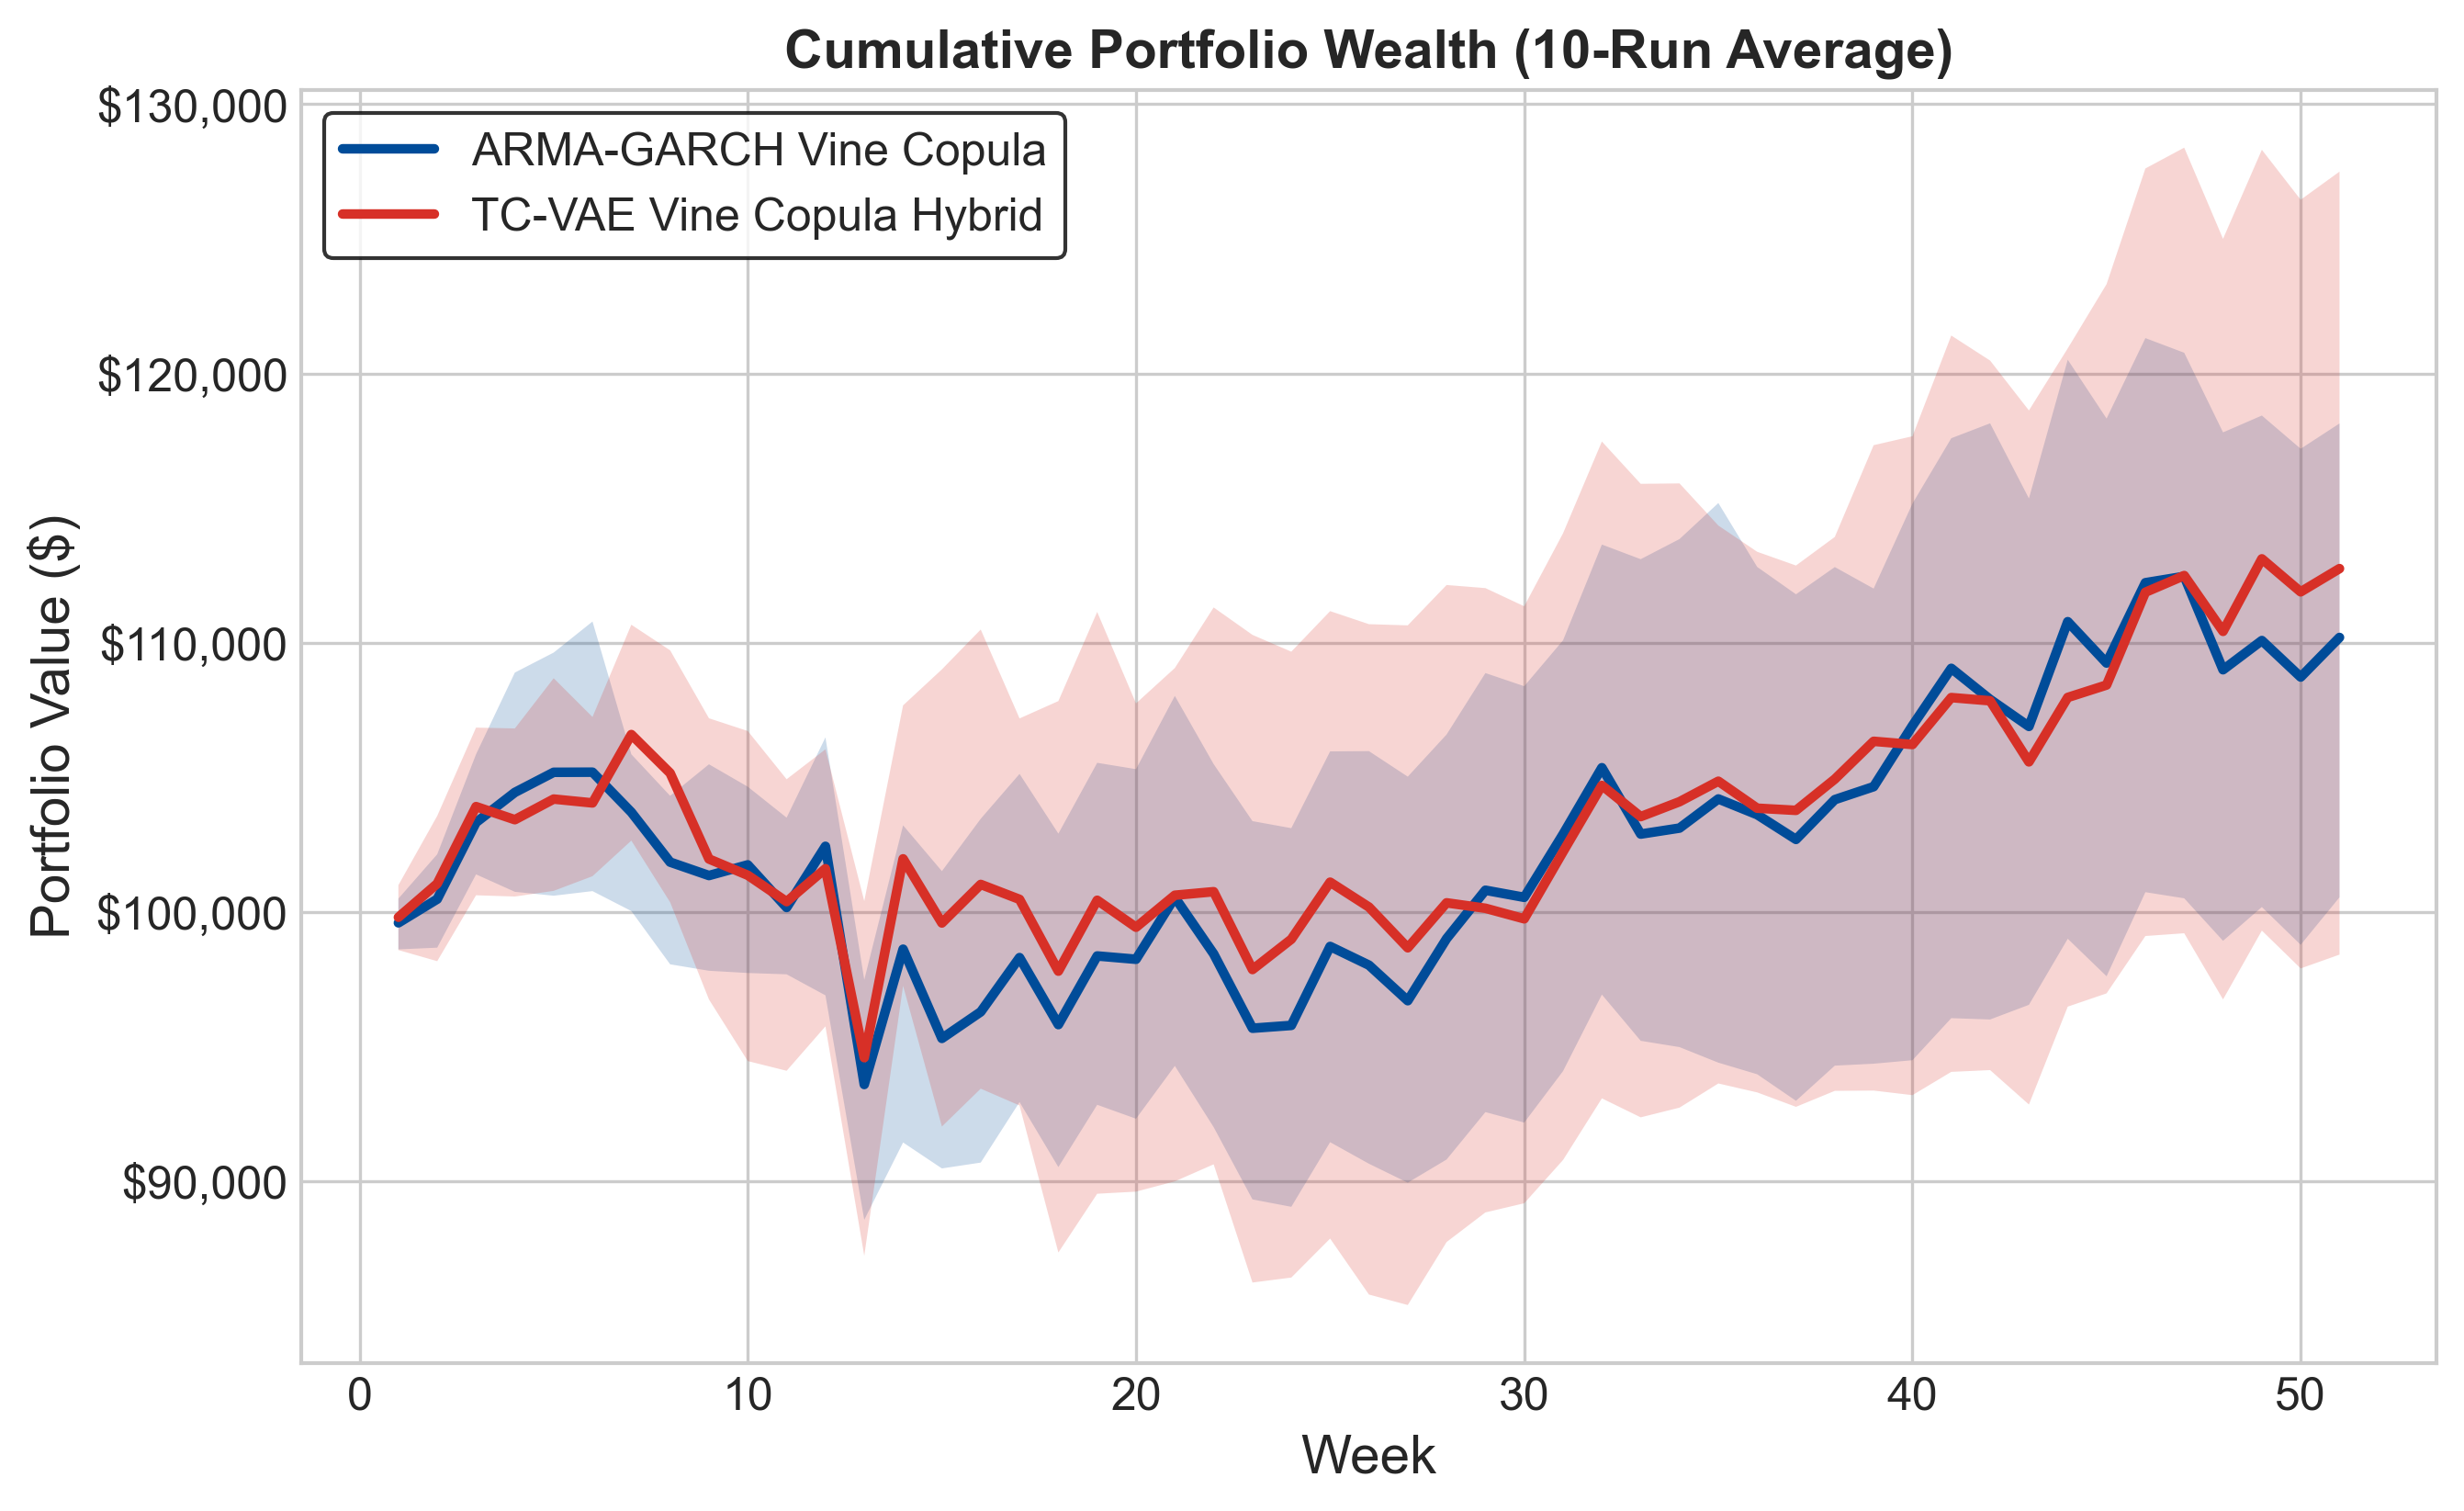

In [5]:
# %% [markdown]
# ### Step 2: Plot 1 - Cumulative Wealth Trajectory with Confidence Intervals
# Computes the mean, 10th percentile, and 90th percentile, and visualizes the stochastic envelope.

# %%
# Calculate summary statistics per Model and Week
stats_df = df.groupby(['Model', 'Week'])['portfolio_value'].agg(
    mean='mean',
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90)
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for model in stats_df['Model'].unique():
    m_data = stats_df[stats_df['Model'] == model]
    
    # Plot the Mean Trajectory
    ax.plot(
        m_data['Week'], m_data['mean'], 
        label=model, 
        color=COLORS[model], 
        linewidth=2.5, 
        zorder=3
    )
    
    # Shade the 10th-90th Percentile Confidence Interval
    ax.fill_between(
        m_data['Week'], 
        m_data['p10'], 
        m_data['p90'], 
        color=COLORS[model], 
        alpha=0.2, 
        edgecolor=None,
        zorder=2
    )

ax.set_title("Cumulative Portfolio Wealth (10-Run Average)")
ax.set_xlabel("Week")
ax.set_ylabel("Portfolio Value ($)")

# Format Y-axis as currency
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

ax.legend(loc='upper left', frameon=True, edgecolor='black')

plt.savefig("plot1_cumulative_wealth.png", bbox_inches='tight')
plt.show()


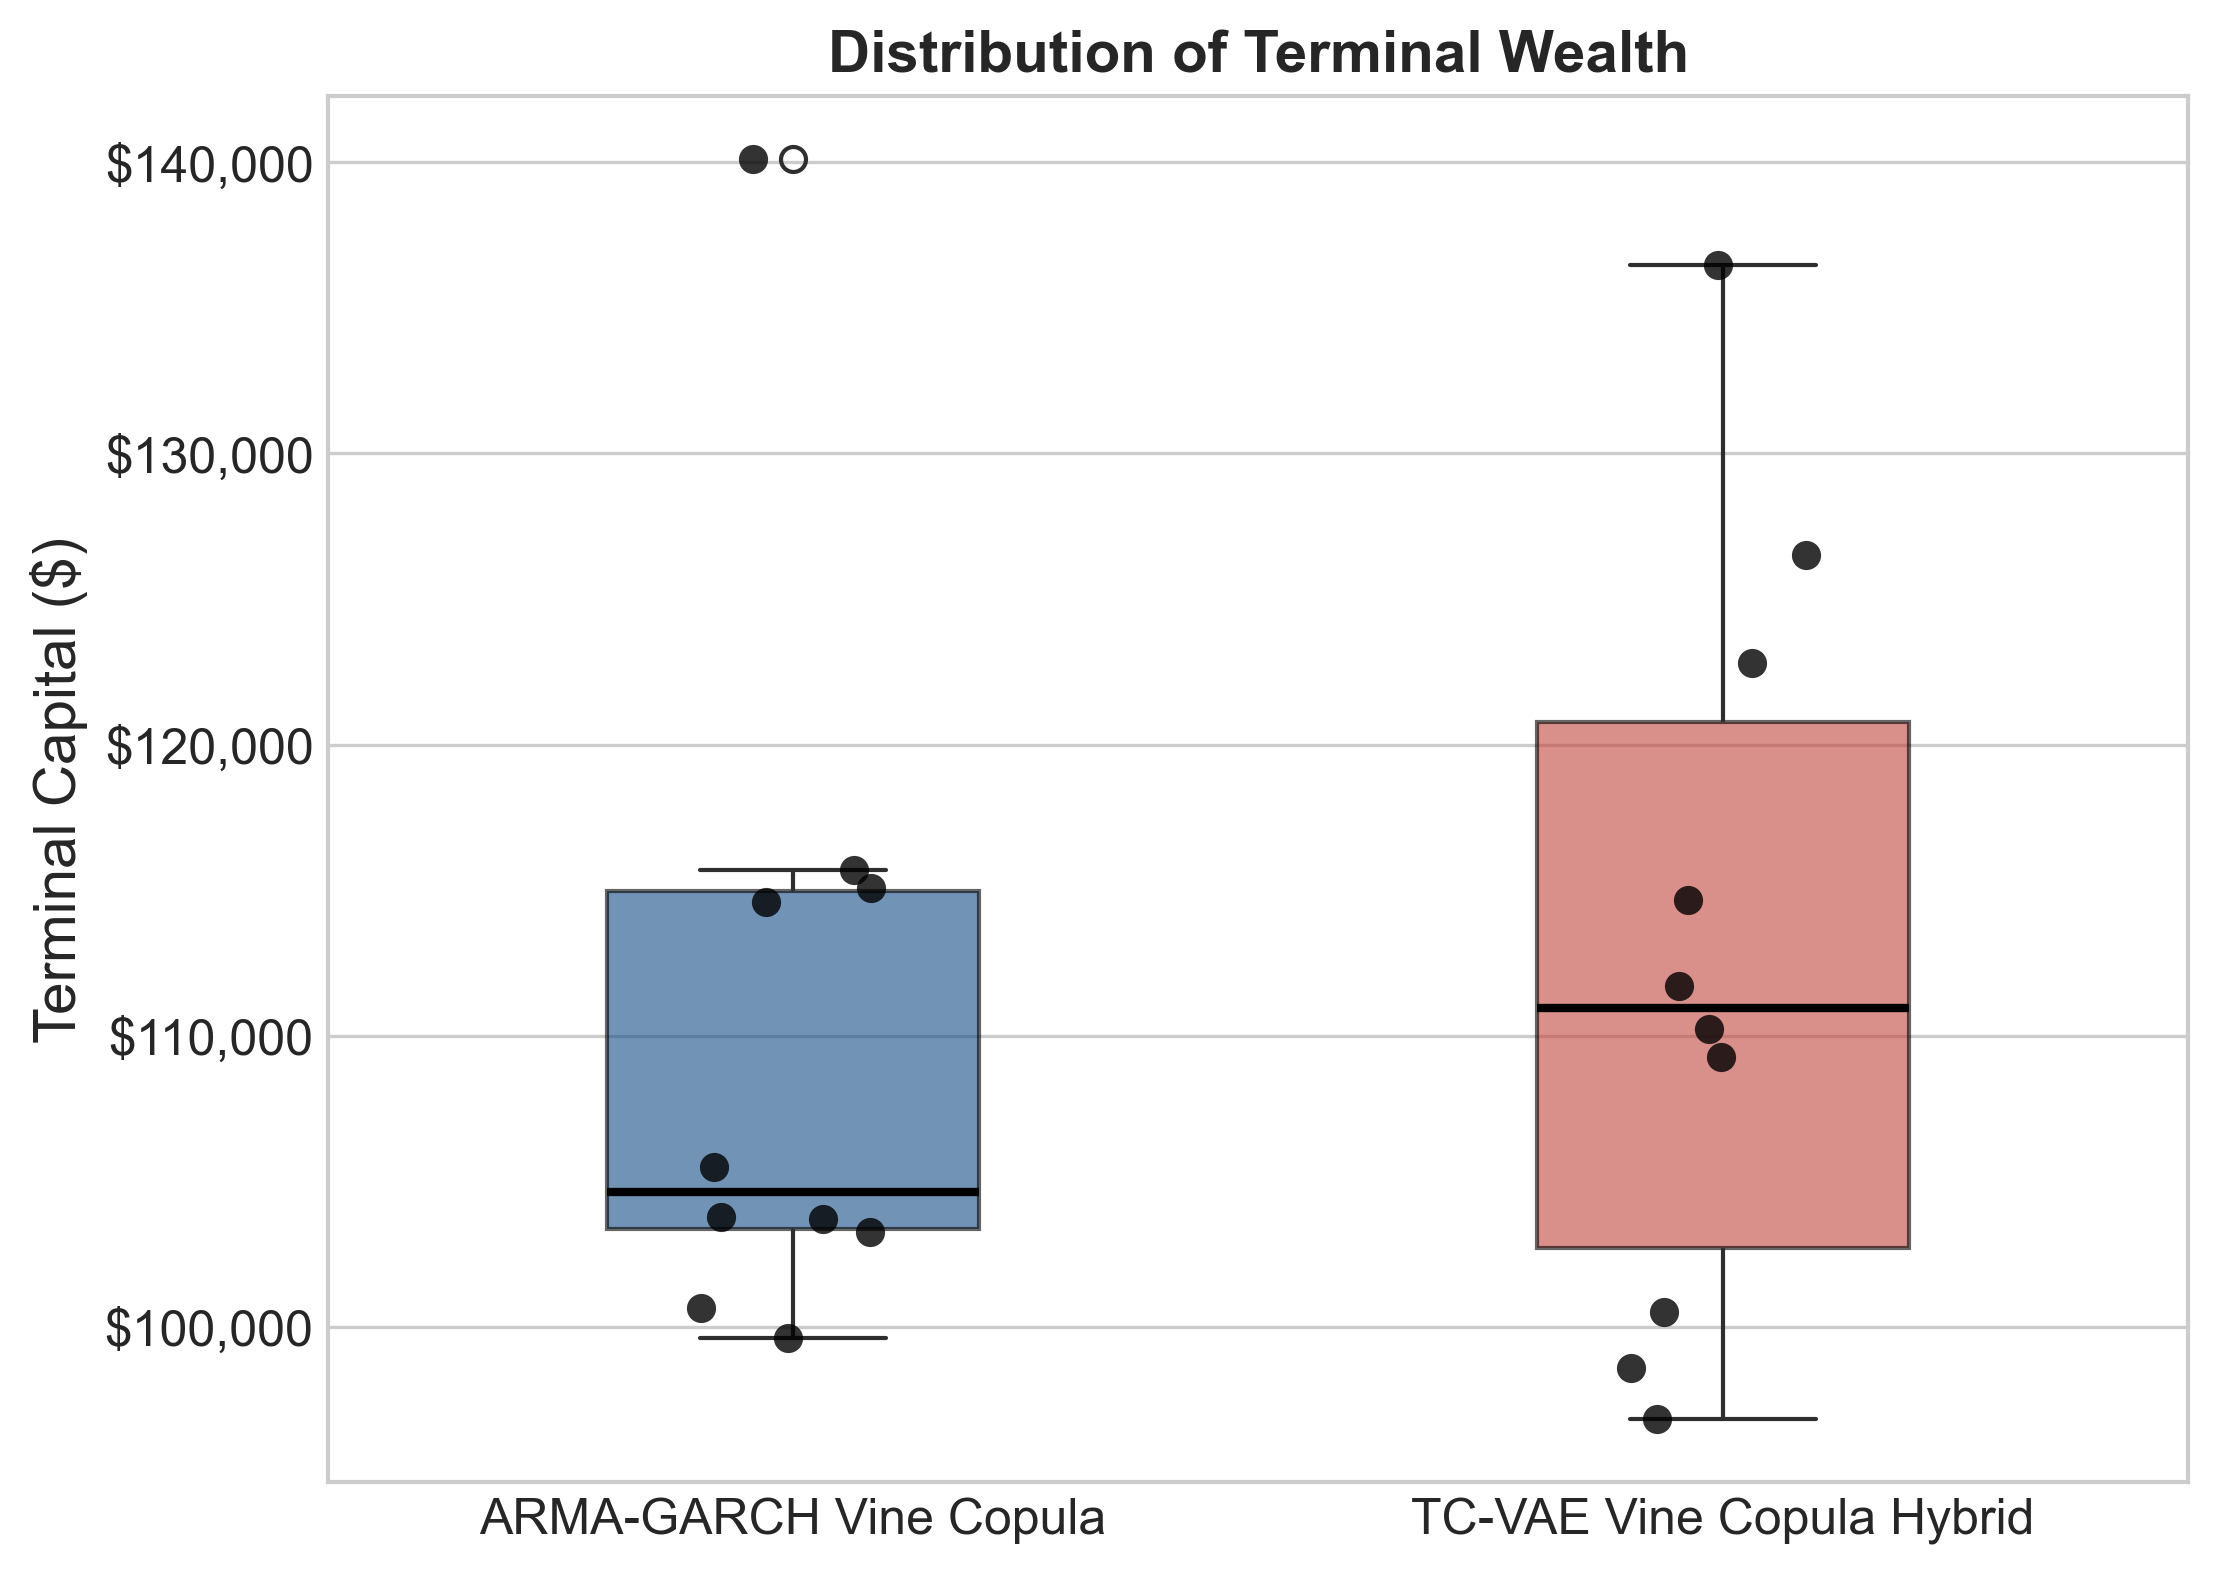

In [6]:
# %% [markdown]
# ### Step 3: Plot 2 - Terminal Wealth Boxplot
# Extracts terminal (Week 52) wealth and plots the distributional spread across the 10 runs.

# %%
# Extract final week data
max_week = df['Week'].max()
terminal_df = df[df['Week'] == max_week].copy()

fig, ax = plt.subplots(figsize=(8, 6))

# Boxplot for distribution shape
sns.boxplot(
    data=terminal_df, 
    x='Model', 
    y='portfolio_value', 
    hue='Model', 
    palette=COLORS, 
    ax=ax, 
    width=0.4,
    boxprops=dict(alpha=0.6, edgecolor='black'),
    medianprops=dict(color='black', linewidth=2),
    legend=False,
    zorder=1
)

# Stripplot overlay to show individual Monte Carlo runs
sns.stripplot(
    data=terminal_df, 
    x='Model', 
    y='portfolio_value', 
    color='black', 
    alpha=0.8, 
    jitter=True, 
    size=7, 
    ax=ax,
    zorder=2
)

ax.set_title(f"Distribution of Terminal Wealth")
ax.set_xlabel("")
ax.set_ylabel("Terminal Capital ($)")

# Format Y-axis as currency
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.savefig("plot2_terminal_wealth.png", bbox_inches='tight')
plt.show()


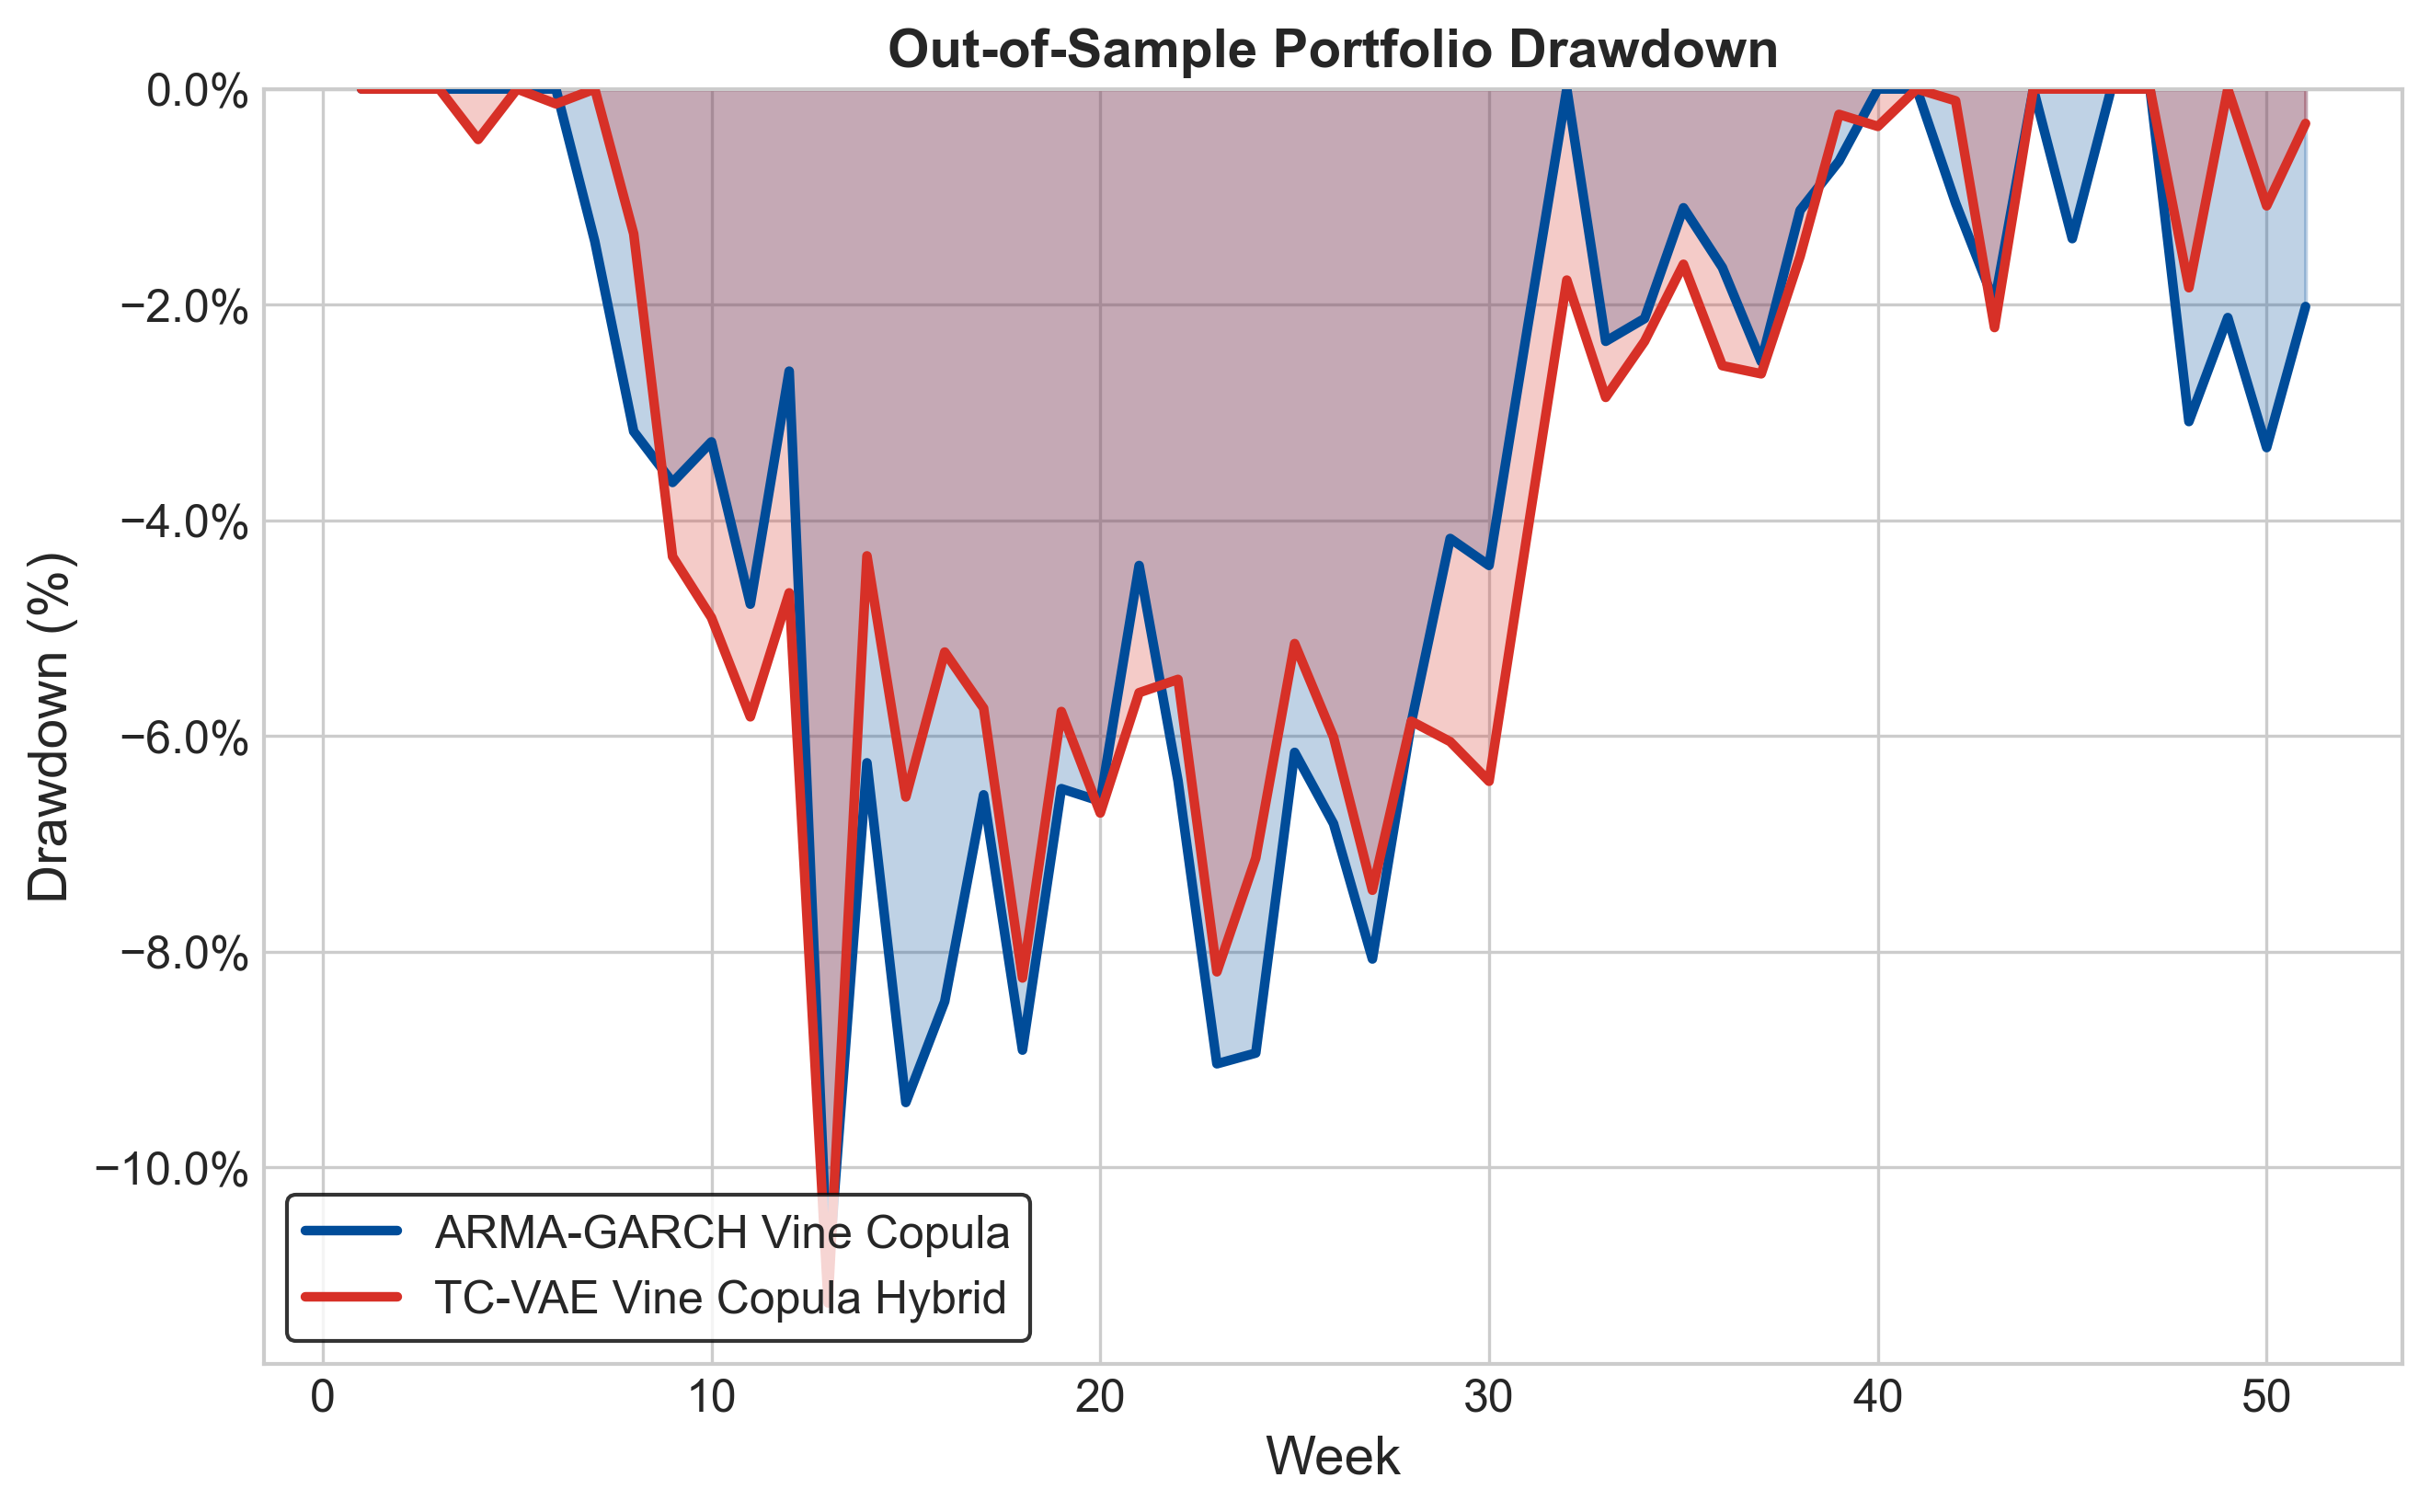

In [7]:
# %% [markdown]
# ### Step 4: Plot 3 - Underwater Plot (Drawdown Trajectory)
# Calculates maximum drawdown percentage based on the mean portfolio trajectory over time.

# %%
# Get the mean trajectory for each model
mean_df = df.groupby(['Model', 'Week'])['portfolio_value'].mean().reset_index()

# Calculate Rolling Maximum and the % Drawdown from that peak
mean_df['rolling_max'] = mean_df.groupby('Model')['portfolio_value'].cummax()
mean_df['drawdown'] = (mean_df['portfolio_value'] - mean_df['rolling_max']) / mean_df['rolling_max']

fig, ax = plt.subplots(figsize=(10, 6))

for model in mean_df['Model'].unique():
    m_data = mean_df[mean_df['Model'] == model]
    
    # Plot drawdown line
    ax.plot(
        m_data['Week'], 
        m_data['drawdown'], 
        label=model, 
        color=COLORS[model], 
        linewidth=2.5,
        zorder=3
    )
    
    # Shade the underwater area from 0 down to the drawdown curve
    ax.fill_between(
        m_data['Week'], 
        0, 
        m_data['drawdown'], 
        color=COLORS[model], 
        alpha=0.25,
        zorder=2
    )

ax.set_title("Out-of-Sample Portfolio Drawdown")
ax.set_xlabel("Week")
ax.set_ylabel("Drawdown (%)")

# Format Y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))

# Optional: Invert Y-axis logically or restrict the top limit to strictly 0%
ax.set_ylim(top=0.0) 

ax.legend(loc='lower left', frameon=True, edgecolor='black')

plt.savefig("plot3_underwater_drawdown.png", bbox_inches='tight')
plt.show()


In [1]:
import numpy as np

In [4]:
import yfinance as yf

In [8]:
data = yf.download('AAPL', start='2025-01-01', end='2026-01-01', interval='1wk')

[*********************100%***********************]  1 of 1 completed


In [9]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-01,240.894058,247.746624,240.038730,247.577534,181886400
2025-01-08,232.012589,242.385930,228.471932,240.605647,188405800
2025-01-15,221.430374,237.661713,218.188092,233.365177,278149800
2025-01-22,236.965530,238.885053,218.595877,218.595877,349630200
2025-01-29,231.535202,245.847021,224.473770,232.848023,320234800
2025-02-05,231.356171,233.951991,225.965619,227.288395,196086800
2025-02-12,243.409119,244.484434,229.678952,230.196700,188576100
2025-02-19,245.967972,248.915134,242.104819,243.598310,217058200


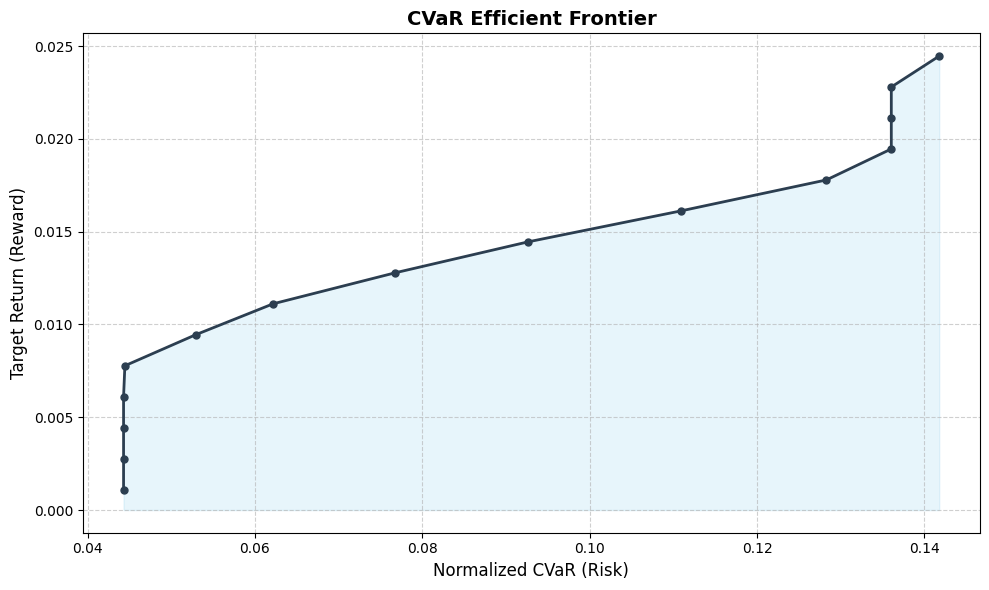

In [ ]:
import matplotlib.pyplot as plt

# Data extracted from your summary table
target_returns = [
    0.001099, 0.002769, 0.004438, 0.006107, 0.007776, 
    0.009446, 0.011115, 0.012784, 0.014454, 0.016123, 
    0.017792, 0.019462, 0.021131, 0.022800, 0.024470
]

normalized_cvar = [
    0.04429136, 0.04429136, 0.04429136, 0.04429136, 0.04444904, 
    0.05290225, 0.06216377, 0.07673124, 0.09263641, 0.11090888, 
    0.12829662, 0.13605116, 0.13605116, 0.13605116, 0.14177833
]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(normalized_cvar, target_returns, marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=5)

# Adding aesthetic elements
plt.title('CVaR Efficient Frontier', fontsize=14, fontweight='bold')
plt.xlabel('Normalized CVaR (Risk)', fontsize=12)
plt.ylabel('Target Return (Reward)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()